**IMPORTS**

In [ ]:
import pandas as pd
import numpy as np

from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

**SYNTHESIZED DATA**

In [ ]:
np.random.seed(42)

n = 50000

modules = [
    "ALU",
    "Instruction_Decoder",
    "Memory_Controller",
    "Cache_Controller",
    "Bus_Interface",
    "DMA_Engine",
    "Interrupt_Controller"
]

tests = [
    "memory_stress_test",
    "cache_eviction_test",
    "interrupt_test",
    "dma_transfer_test",
    "alu_overflow_test",
    "pipeline_test",
    "bus_protocol_test"
]

errors = [
    "None",
    "Assertion Failure",
    "Timing Violation",
    "Protocol Error",
    "Overflow",
    "Deadlock"
]

data = {
    "regression_id": np.random.randint(1000, 2000, n),
    "test_name": np.random.choice(tests, n),
    "module": np.random.choice(modules, n),
    "seed": np.random.randint(1, 100000, n),
    "code_coverage": np.random.uniform(50, 100, n),
    "functional_coverage": np.random.uniform(40, 100, n),
    "assertions_failed": np.random.randint(0, 5, n),
    "simulation_time": np.random.uniform(20, 500, n),
    "lines_modified": np.random.randint(0, 200, n),
    "prior_failures": np.random.randint(0, 10, n),
    "engineer_experience": np.random.randint(1, 10, n),
    "error_type": np.random.choice(errors, n)
}

df = pd.DataFrame(data)

# realistic failure probability
failure_score = (
    (100 - df["code_coverage"]) * 0.03
    + (100 - df["functional_coverage"]) * 0.02
    + df["lines_modified"] * 0.01
    + df["prior_failures"] * 0.3
    + df["assertions_failed"] * 0.4
)

df["result"] = (failure_score > 4).astype(int)

df.to_csv("rtl_verification_dataset.csv", index=False)

print("Dataset generated:", df.shape)

Dataset generated: (50000, 13)


**LOAD DATA**

In [ ]:
df = pd.read_csv("rtl_verification_dataset.csv")

print(df.head())
print(df.info())
print(df.describe())

   regression_id           test_name                module   seed  \
0           1102  memory_stress_test  Interrupt_Controller  72109   
1           1435   bus_protocol_test            DMA_Engine  80300   
2           1860      interrupt_test   Instruction_Decoder  74181   
3           1270   dma_transfer_test   Instruction_Decoder  87168   
4           1106   dma_transfer_test            DMA_Engine  57053   

   code_coverage  functional_coverage  assertions_failed  simulation_time  \
0      89.382281            51.382241                  2        33.770444   
1      92.480891            67.884499                  2       422.344208   
2      83.331917            94.724591                  2       150.150807   
3      51.866267            80.623254                  1       167.879798   
4      67.623889            46.197379                  1       229.378158   

   lines_modified  prior_failures  engineer_experience         error_type  \
0             199               0            

In [ ]:
df = df.rename(columns={
    "lines_modified": "lines_changed",
    "prior_failures": "previous_failures",
    "result": "pass_fail"
})

**FEATURE ENGINEERING**

In [ ]:
df["change_risk"] = df["lines_changed"] * df["previous_failures"]

**FAILURE TEXT**

In [ ]:
df["failure_text"] = (
    df["module"].astype(str) + " " +
    df["error_type"].astype(str) + " " +
    df["lines_changed"].astype(str) + " " +
    df["previous_failures"].astype(str)
)

**ENCODING**

In [ ]:
df = pd.get_dummies(
    df,
    columns=["module", "error_type"],
    drop_first=True
)

**TRAIN & TEST**

In [ ]:
X = df.drop(["pass_fail", "failure_text", "test_name"], axis=1)
y = df["pass_fail"]

print(X.shape)
print(y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

(50000, 20)
(50000,)


**bold text**

In [ ]:
model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 25531, number of negative: 14469
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011162 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1775
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.638275 -> initscore=0.567885
[LightGBM] [Info] Start training from score 0.567885


LGBMClassifier(learning_rate=0.05, max_depth=6, n_estimators=200,
               random_state=42)

In [ ]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9858
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3487
           1       0.99      0.99      0.99      6513

    accuracy                           0.99     10000
   macro avg       0.99      0.98      0.98     10000
weighted avg       0.99      0.99      0.99     10000



In [ ]:
probs = model.predict_proba(X_test)

failure_prob = probs[:,1]

print(failure_prob[:10])

[0.99223892 0.99981886 0.00555362 0.98802542 0.00432748 0.01551747
 0.99980635 0.99783336 0.99861205 0.02092681]


In [ ]:
risk_df = X_test.copy()

risk_df["failure_probability"] = failure_prob
risk_df["actual_result"] = y_test.values

risk_df = risk_df.sort_values(
    "failure_probability",
    ascending=False
)

print(risk_df.head(10))

       regression_id   seed  code_coverage  functional_coverage  \
33177           1087  77951      53.591399            44.158400   
21522           1086  71421      53.314902            54.754710   
21374           1370  58162      52.325464            44.394644   
38902           1931  24806      54.339553            47.224730   
16476           1010  51971      55.467786            43.797617   
16749           1513  33535      53.588137            51.726507   
24650           1771  43169      51.053784            59.637075   
36359           1626  92483      52.112046            62.707235   
25088           1150  20891      53.068366            54.211529   
12487           1809  53622      55.177178            48.762032   

       assertions_failed  simulation_time  lines_changed  previous_failures  \
33177                  4       137.547273             83                  8   
21522                  4       118.469263             85                  9   
21374                  4 

In [ ]:
importance = model.feature_importances_

feature_importance = pd.Series(
    importance,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance.head(10))

code_coverage          1270
change_risk            1180
assertions_failed      1076
functional_coverage    1000
previous_failures       871
lines_changed           567
regression_id            13
simulation_time          11
seed                      9
engineer_experience       1
dtype: int32


In [ ]:
vectorizer = TfidfVectorizer()

failure_vectors = vectorizer.fit_transform(df["failure_text"])

def find_similar_failures(index, top_n=5):

    query_vector = failure_vectors[index]

    similarities = cosine_similarity(query_vector, failure_vectors).flatten()

    similar_indices = similarities.argsort()[-top_n-1:-1][::-1]

    return df.iloc[similar_indices]

    find_similar_failures(10)

In [ ]:
planner_df = df.copy()

planner_df["risk_score"] = model.predict_proba(X)[:,1]

planner_df = planner_df.sort_values(
    "risk_score",
    ascending=False
)

In [ ]:
def regression_planner(time_budget):

    selected_tests = []
    total_time = 0

    for _, row in planner_df.iterrows():

        runtime = row["simulation_time"]

        if total_time + runtime <= time_budget:
            selected_tests.append(row)
            total_time += runtime

    return pd.DataFrame(selected_tests)

In [ ]:
recommended_tests = regression_planner(2000)

print(recommended_tests[
    ["test_name", "simulation_time", "risk_score"]
].head(10))

                 test_name  simulation_time  risk_score
46821       interrupt_test       432.114205    0.999930
48940        pipeline_test        70.394586    0.999929
3925        interrupt_test       200.861572    0.999929
31203    bus_protocol_test       272.171314    0.999929
42711        pipeline_test       282.426105    0.999929
15859   memory_stress_test       125.377785    0.999929
47812  cache_eviction_test       263.448495    0.999929
33177       interrupt_test       137.547273    0.999929
21522    bus_protocol_test       118.469263    0.999928
48374    alu_overflow_test        38.575126    0.999928


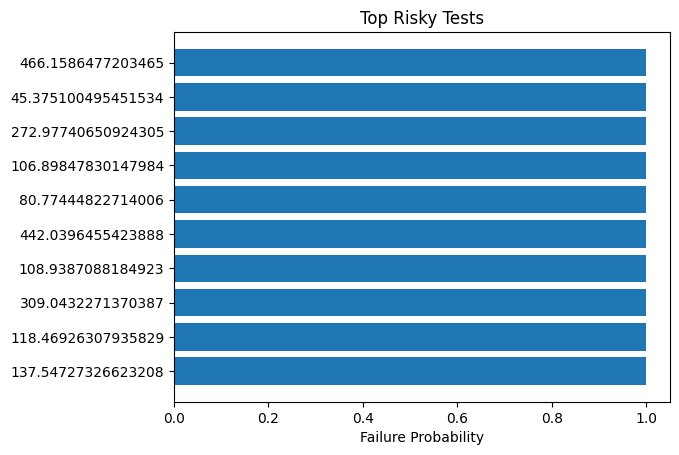

In [ ]:
import matplotlib.pyplot as plt

top = risk_df.head(10)

plt.barh(range(len(top)), top["failure_probability"])
plt.yticks(range(len(top)), top["simulation_time"])
plt.xlabel("Failure Probability")
plt.title("Top Risky Tests")
plt.show()

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(
/tmp/ipykernel_39891/945500869.py:4: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


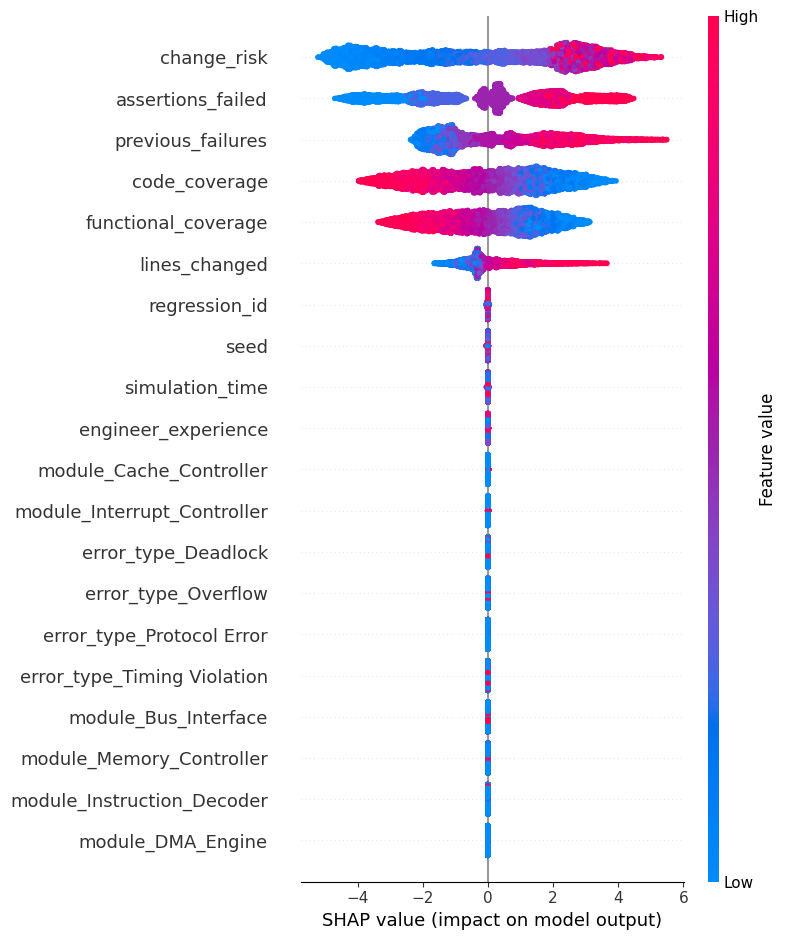

In [ ]:
import shap
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

In [ ]:
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0]

)

In [ ]:
def explain_failure(index, top_n=3):

    shap_values_single = shap_values[index]

    feature_names = X_test.columns

    contributions = list(zip(feature_names, shap_values_single))

    contributions = sorted(contributions, key=lambda x: abs(x[1]), reverse=True)

    return contributions[:top_n]

In [ ]:
def failure_reason(index):

    reasons = explain_failure(index)

    print("AI Failure Explanation:\n")

    for feature, value in reasons:
        if value > 0:
            print(f"• High {feature} increased failure risk")
        else:
            print(f"• Low {feature} reduced system stability")

In [ ]:
def build_failure_log(index):

    row = df.iloc[index]

    text = f"""
    Module: {row['module']}
    Assertions Failed: {row['assertions_failed']}
    Previous Failures: {row['previous_failures']}
    Lines Changed: {row['lines_changed']}
    Code Coverage: {row['code_coverage']}
    Functional Coverage: {row['functional_coverage']}
    """

    return text

In [ ]:
def summarize_failure(index):

    row = df.iloc[index]

    summary = []

    if row["assertions_failed"] > 2:
        summary.append("Multiple assertion violations detected.")

    if row["previous_failures"] > 5:
        summary.append("The module has a history of repeated failures.")

    if row["lines_changed"] > 80:
        summary.append("Large number of RTL code modifications recently.")

    if row["code_coverage"] < 70:
        summary.append("Low code coverage indicates untested logic.")

    if row["functional_coverage"] < 60:
        summary.append("Functional coverage is insufficient.")

    print("AI Failure Summary:\n")

    for s in summary:
        print("•", s)


In [ ]:
def regression_advisor(index):

    row = df.iloc[index]

    advice = []

    if row["assertions_failed"] > 2:
        advice.append("Investigate assertion violations in the module.")

    if row["previous_failures"] > 5:
        advice.append("Check historical bugs in this module.")

    if row["lines_changed"] > 80:
        advice.append("Review recently modified RTL code.")

    if row["code_coverage"] < 70:
        advice.append("Increase code coverage before next regression.")

    if row["functional_coverage"] < 60:
        advice.append("Add more functional verification scenarios.")

    print("\nAI Verification Advisor\n")

    for a in advice:
        print("•", a)

In [ ]:
failure_reason(0)
print("")
summarize_failure(10)
print("")
regression_advisor(10)

AI Failure Explanation:

• High change_risk increased failure risk
• Low assertions_failed reduced system stability
• High code_coverage increased failure risk

AI Failure Summary:

• Multiple assertion violations detected.
• The module has a history of repeated failures.
• Functional coverage is insufficient.


AI Verification Advisor

• Investigate assertion violations in the module.
• Check historical bugs in this module.
• Add more functional verification scenarios.


In [ ]:
original_df = pd.read_csv("rtl_verification_dataset.csv")
y_error = original_df["error_type"].fillna("None")

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_error_encoded = le.fit_transform(y_error)

In [ ]:
X = df.drop(["pass_fail","failure_text","test_name"], axis=1)

In [ ]:
from sklearn.model_selection import train_test_split

X_train_e, X_test_e, y_error_train, y_error_test = train_test_split(
    X,
    y_error_encoded,
    test_size=0.2,
    random_state=42
)

In [ ]:
X_train_e = X_train_e.replace([np.inf, -np.inf], 0).fillna(0)
X_test_e = X_test_e.replace([np.inf, -np.inf], 0).fillna(0)

In [ ]:
from lightgbm import LGBMClassifier

error_model = LGBMClassifier()

error_model.fit(X_train_e, y_error_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003181 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1775
[LightGBM] [Info] Number of data points in the train set: 40000, number of used features: 20
[LightGBM] [Info] Start training from score -1.792910
[LightGBM] [Info] Start training from score -1.807127
[LightGBM] [Info] Start training from score -1.794563
[LightGBM] [Info] Start training from score -1.803174
[LightGBM] [Info] Start training from score -1.779930
[LightGBM] [Info] Start training from score -1.773281
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warnin

LGBMClassifier()

In [ ]:
predicted_error = error_model.predict(X_test_e)

print(le.inverse_transform(predicted_error[:10]))

['Assertion Failure' 'Timing Violation' 'Protocol Error' 'Overflow'
 'Timing Violation' 'Assertion Failure' 'Timing Violation'
 'Assertion Failure' 'Deadlock' 'Deadlock']


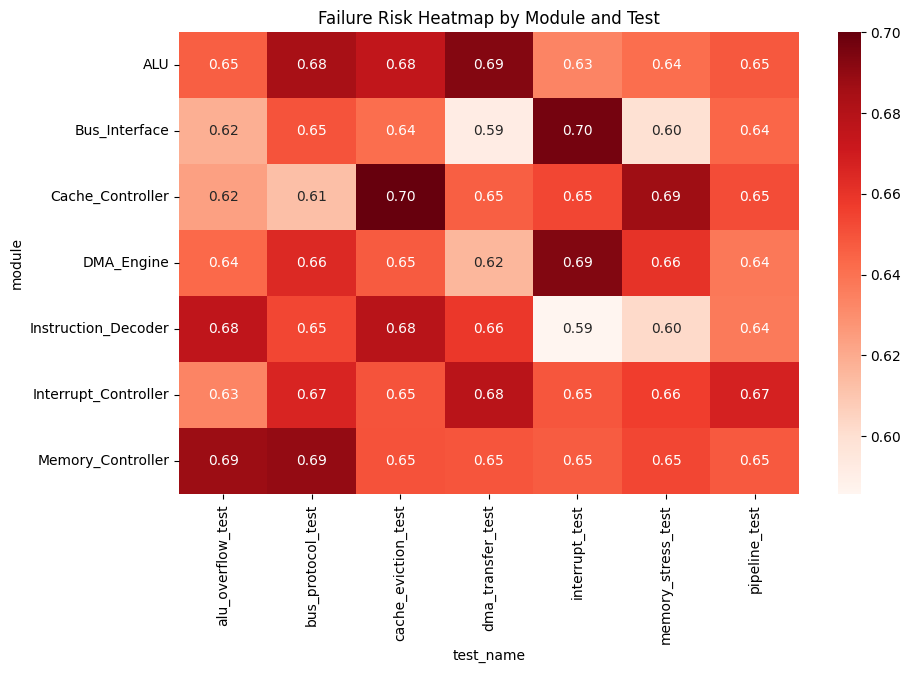

In [ ]:
heatmap_df = risk_df.copy()

heatmap_df["test_name"] = original_df.loc[heatmap_df.index, "test_name"]
heatmap_df["module"] = original_df.loc[heatmap_df.index, "module"]

pivot = heatmap_df.pivot_table(
    values="failure_probability",
    index="module",
    columns="test_name",
    aggfunc="mean"
)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    pivot,
    cmap="Reds",
    annot=True,
    fmt=".2f"
)

plt.title("Failure Risk Heatmap by Module and Test")
plt.show()